# QFlow Lite — Dimensionality Reduction & Similarity Analysis

**Goal:** Understand how quantum dot device states cluster in feature space and  
how similar they are to each other, using multiple complementary techniques.

**Part A — Dimensionality Reduction (visualisation)**
| Method | Type | Key property |
|--------|------|--------------|
| **PCA** | Linear | Fast, global variance, interpretable axes |
| **t-SNE** | Non-linear | Preserves local neighbourhoods, reveals clusters |
| **UMAP** | Non-linear | Preserves both local & global structure, faster than t-SNE |
| **Kernel PCA** | Non-linear | RBF kernel, captures nonlinear manifold |
| **Isomap** | Non-linear | Geodesic distances on manifold |
| **MDS** | Non-linear | Preserves pairwise Euclidean distances |

**Part B — Similarity Analysis (high-dimensional)**
- Cosine similarity matrix between class centroids  
- Euclidean / Mahalanobis inter-class distance matrices  
- k-NN purity (how often are neighbours from the same class?)  
- Silhouette scores per class  
- Davies-Bouldin & Calinski-Harabasz clustering quality indices  
- Pairwise sample similarity heatmap  
- Nearest-neighbour retrieval examples  


In [3]:
import sklearn, umap
print(f"scikit-learn : {sklearn.__version__}")
print(f"umap-learn   : {umap.__version__}")


C:\Users\Lehma\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



scikit-learn : 1.7.2
umap-learn   : 0.5.12


## 1 · Imports & configuration

In [4]:
import os, time, warnings, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from pathlib import Path
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import spearmanr

import umap
from sklearn.manifold import TSNE, Isomap, MDS
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    pairwise_distances
)
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi"  : 110,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "font.family" : "DejaVu Sans"
})

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Colour palette — one per class
PALETTE = ["#e63946", "#2a9d8f", "#e9c46a", "#457b9d"]
MARKERS = ["o", "s", "^", "D"]
print("Imports complete.")


Imports complete.


## 2 · Configuration

In [5]:
DATA_DIR = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite")
OUT_DIR  = Path(r"C:/Users/Lehma/AIProjects/data_qflow_lite/dimred_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = {0: "Barrier", 1: "Single Dot",
               2: "Double Dot", 3:"Short Circuit"}
N_CLASSES   = 4
ALL_LABELS  = sorted(LABEL_NAMES.keys())
CLASS_NAMES = [LABEL_NAMES[k] for k in ALL_LABELS]

# Feature params
N_PCA_FEATURES = 128   # PCA components per channel for flat features

# t-SNE params
TSNE_PERPLEXITY = 40
TSNE_ITER       = 2000

# UMAP params
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.1

# Similarity params
N_NEIGHBORS_KNN  = 15   # for kNN purity
N_SIMILAR_SHOW   = 5    # nearest neighbours to display per query

print("Configuration ready.")



Configuration ready.


## 3 · Load dataset

In [6]:
def charge_to_float(c):
    try:
        return float(len(c)) if hasattr(c, '__len__') else float(c)
    except Exception:
        return 0.0

def load_dataset(data_dir):
    files = sorted([f for f in os.listdir(data_dir)
                    if f.endswith('.npy') and not f.startswith('.')])
    currents, coulombs, occupancies, labels = [], [], [], []
    skipped = 0
    for fname in files:
        try:
            raw    = np.load(data_dir / fname, allow_pickle=True).item()
            output = raw['output']
            if len(output) != 10000:
                skipped += 1; continue
            cur = np.array([p['current'] for p in output],
                           dtype=np.float32).reshape(100, 100)
            sen = np.array([p['sensor'][0] if hasattr(p['sensor'], '__len__')
                            else float(p['sensor']) for p in output],
                           dtype=np.float32).reshape(100, 100)
            chg = np.array([charge_to_float(p['charge']) for p in output],
                           dtype=np.float32).reshape(100, 100)
            states = [p['state'] for p in output]
            label  = int(max(set(states), key=states.count))
            currents.append(cur); coulombs.append(sen)
            occupancies.append(chg); labels.append(label)
        except Exception:
            skipped += 1
    if skipped: print(f"Skipped {skipped} files.")
    return (np.stack(currents).astype(np.float32),
            np.stack(coulombs).astype(np.float32),
            np.stack(occupancies).astype(np.float32),
            np.array(labels, dtype=np.int64))

print("Loading …")
current, coulomb, occupancy, labels = load_dataset(DATA_DIR)
print(f"Loaded {len(labels)} samples  |  Shape: {current[0].shape}")
print("\nClass distribution:")
for k, name in LABEL_NAMES.items():
    n   = (labels == k).sum()
    bar = "█" * int(n / len(labels) * 40)
    print(f"  {name:<14} ({k})  {n:>4}  {bar}")


Loading …
Loaded 1001 samples  |  Shape: (100, 100)

Class distribution:
  Barrier        (0)    18  
  Single Dot     (1)   756  ██████████████████████████████
  Double Dot     (2)   227  █████████
  Short Circuit  (3)     0  


## 4 · Feature extraction

We build **two** feature representations for comparison:

- **Flat (426-d):** per-channel statistics + PCA → used for all reduction methods  
- **Raw pixels (30 000-d):** flattened 3 × 100 × 100 maps → used to show UMAP handles raw input


In [7]:
def channel_stats(maps):
    N    = len(maps)
    flat = maps.reshape(N, -1)
    p    = np.percentile(flat, [10,20,30,40,50,60,70,80,90], axis=1).T
    mu   = flat.mean(1, keepdims=True)
    sg   = flat.std(1,  keepdims=True) + 1e-8
    skew = ((flat - mu)**3).mean(1, keepdims=True) / (sg**3)
    return np.hstack([mu, sg, flat.min(1,keepdims=True),
                      flat.max(1,keepdims=True), skew, p])

def build_flat_features(cur, cou, occ, n_pca=N_PCA_FEATURES):
    N     = len(cur)
    stats = np.hstack([channel_stats(cur),
                       channel_stats(cou),
                       channel_stats(occ)])          # (N, 42)
    pca_parts = []
    for ch in [cur, cou, occ]:
        flat  = ch.reshape(N, -1)
        flat_s = StandardScaler().fit_transform(flat)
        k     = min(n_pca, flat_s.shape[1], N - 1)
        pca_parts.append(
            PCA(k, random_state=SEED).fit_transform(flat_s))
    return np.hstack([stats] + pca_parts)            # (N, 42+3*128)

print("Building flat features (426-d) …")
t0     = time.time()
X_flat = build_flat_features(current, coulomb, occupancy)
print(f"  Done in {time.time()-t0:.1f}s  shape: {X_flat.shape}")

# Standardise flat features
X_sc   = StandardScaler().fit_transform(X_flat)

# Log-normalise raw pixel stack for raw-pixel experiments
def log_norm_ch(maps):
    m  = np.sign(maps) * np.log1p(np.abs(maps))
    mn = m.min((1,2), keepdims=True)
    mx = m.max((1,2), keepdims=True)
    d  = np.where(mx-mn == 0, 1.0, mx-mn)
    return ((m - mn) / d).astype(np.float32)

print("Building raw pixel features (30 000-d).")
X_raw = np.concatenate([
    log_norm_ch(current).reshape(len(labels), -1),
    log_norm_ch(coulomb).reshape(len(labels), -1),
    log_norm_ch(occupancy).reshape(len(labels), -1),
], axis=1)
print(f"Done. Shape: {X_raw.shape}")

# Sub-sample for heavy methods (t-SNE, MDS, Isomap)
N_SUBSAMPLE = min(800, len(labels))
rng = np.random.default_rng(SEED)
sub_idx = rng.choice(len(labels), N_SUBSAMPLE, replace=False)
X_sub   = X_sc[sub_idx]
y_sub   = labels[sub_idx]
print(f"\nSubsample for heavy methods: {N_SUBSAMPLE} samples")


Building flat features (426-d) …
  Done in 7.5s  shape: (1001, 426)
Building raw pixel features (30 000-d).
Done. Shape: (1001, 30000)

Subsample for heavy methods: 800 samples


## 5 · Shared scatter plot helper

In [8]:
def scatter_2d(coords, y, ax, title="", alpha=0.65, s=18,
               show_centroids=True, show_legend=True,
               decision_bg=False):
    """
    2D scatter with class colours and optional centroids.
    coords : (N, 2)
    y      : (N,)  int labels
    """
    for cls_idx in ALL_LABELS:
        mask = y == cls_idx
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=PALETTE[cls_idx], marker=MARKERS[cls_idx],
                   s=s, alpha=alpha, linewidths=0,
                   label=LABEL_NAMES[cls_idx])
    if show_centroids:
        for cls_idx in ALL_LABELS:
            mask = y == cls_idx
            if mask.sum() == 0: continue
            cx, cy = coords[mask, 0].mean(), coords[mask, 1].mean()
            ax.scatter(cx, cy, c=PALETTE[cls_idx], marker="X",
                       s=200, edgecolors="black", linewidths=1.2, zorder=10)
            ax.annotate(LABEL_NAMES[cls_idx].split()[0],
                        (cx, cy), fontsize=7, fontweight="bold",
                        xytext=(4, 4), textcoords="offset points")
    if show_legend:
        ax.legend(fontsize=7, markerscale=1.5, loc="best")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2")
    ax.grid(alpha=0.2)

def save_fig(fig, name):
    #fig.savefig(OUT_DIR / name, dpi=120, bbox_inches="tight")
    plt.show(); plt.close(fig)
    print("Done")

print("Plot helpers ready.")


Plot helpers ready.


## 6 · PCA — Linear baseline

PCA finds directions of maximum variance. The first two components explain the  
most variance overall but may not separate classes optimally.


Running PCA
PCA variance explained: PC1=3.7%  PC2=2.2%  Total=5.9%


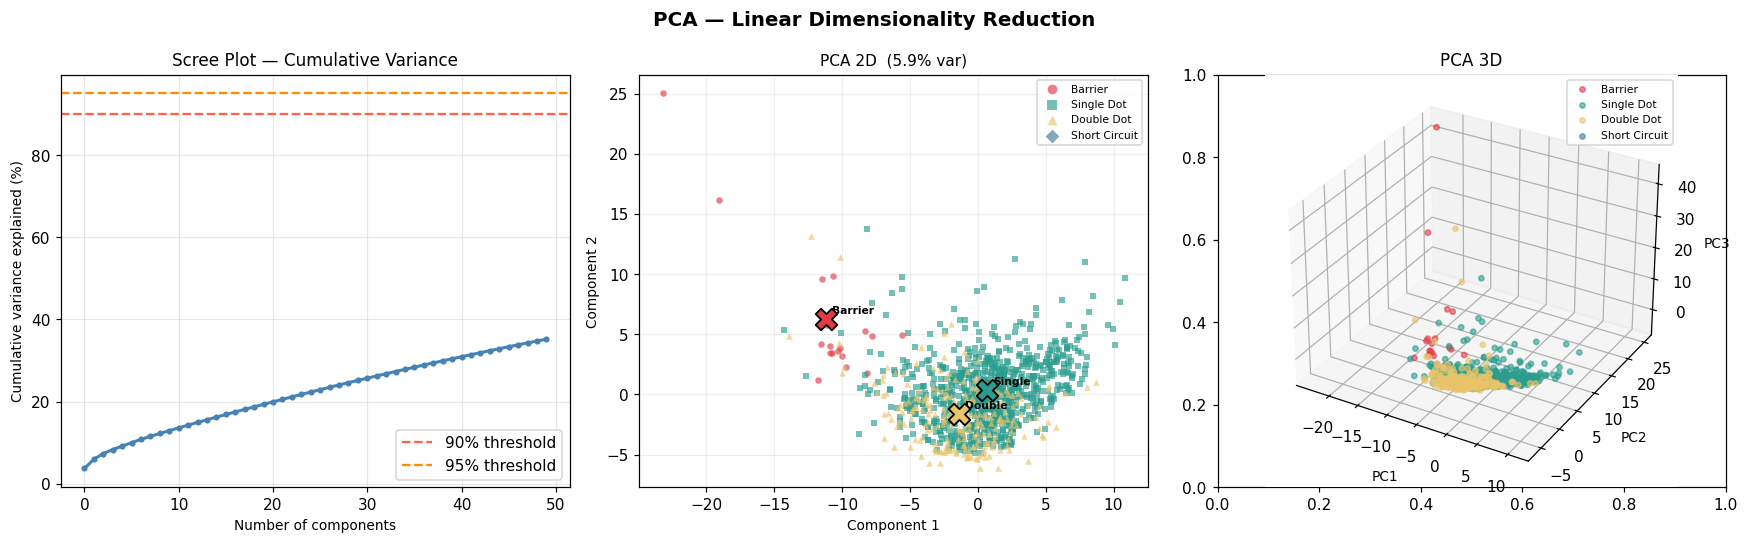

Done


In [9]:
print("Running PCA")
pca_2d   = PCA(n_components=2, random_state=SEED)
X_pca    = pca_2d.fit_transform(X_sc)

# Also 3D for reference
pca_3d   = PCA(n_components=3, random_state=SEED)
X_pca3   = pca_3d.fit_transform(X_sc)

var_explained = pca_2d.explained_variance_ratio_
print(f"PCA variance explained: PC1={var_explained[0]*100:.1f}%  "
      f"PC2={var_explained[1]*100:.1f}%  "
      f"Total={var_explained.sum()*100:.1f}%")

# Scree plot + scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("PCA — Linear Dimensionality Reduction", fontsize=13, fontweight="bold")

# Scree
pca_full = PCA(n_components=50, random_state=SEED).fit(X_sc)
axes[0].plot(np.cumsum(pca_full.explained_variance_ratio_) * 100,
             color="steelblue", lw=2, marker="o", ms=3)
axes[0].axhline(90, color="tomato", ls="--", label="90% threshold")
axes[0].axhline(95, color="darkorange", ls="--", label="95% threshold")
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Cumulative variance explained (%)")
axes[0].set_title("Scree Plot — Cumulative Variance")
axes[0].legend(); axes[0].grid(alpha=0.3)

# 2D scatter
scatter_2d(X_pca, labels, axes[1],
           title=f"PCA 2D  ({var_explained.sum()*100:.1f}% var)")

# 3D scatter
ax3d = fig.add_subplot(1, 3, 3, projection="3d")
for cls_idx in ALL_LABELS:
    mask = labels == cls_idx
    ax3d.scatter(X_pca3[mask,0], X_pca3[mask,1], X_pca3[mask,2],
                 c=PALETTE[cls_idx], label=LABEL_NAMES[cls_idx],
                 s=12, alpha=0.6)
ax3d.set_title("PCA 3D")
ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
ax3d.legend(fontsize=7)
axes[1].get_figure()  # keep reference

plt.tight_layout()
save_fig(fig, "pca_analysis.png")


## 7 · t-SNE — Non-linear local structure

t-SNE converts pairwise similarities to probabilities and minimises  
KL-divergence between high- and low-dimensional distributions.  
We compare three perplexity settings to show sensitivity.


  Running t-SNE (perplexity=10) … 4.3s  KL=1.9410
  Running t-SNE (perplexity=30) … 4.4s  KL=1.7727
  Running t-SNE (perplexity=40) … 5.5s  KL=1.6173


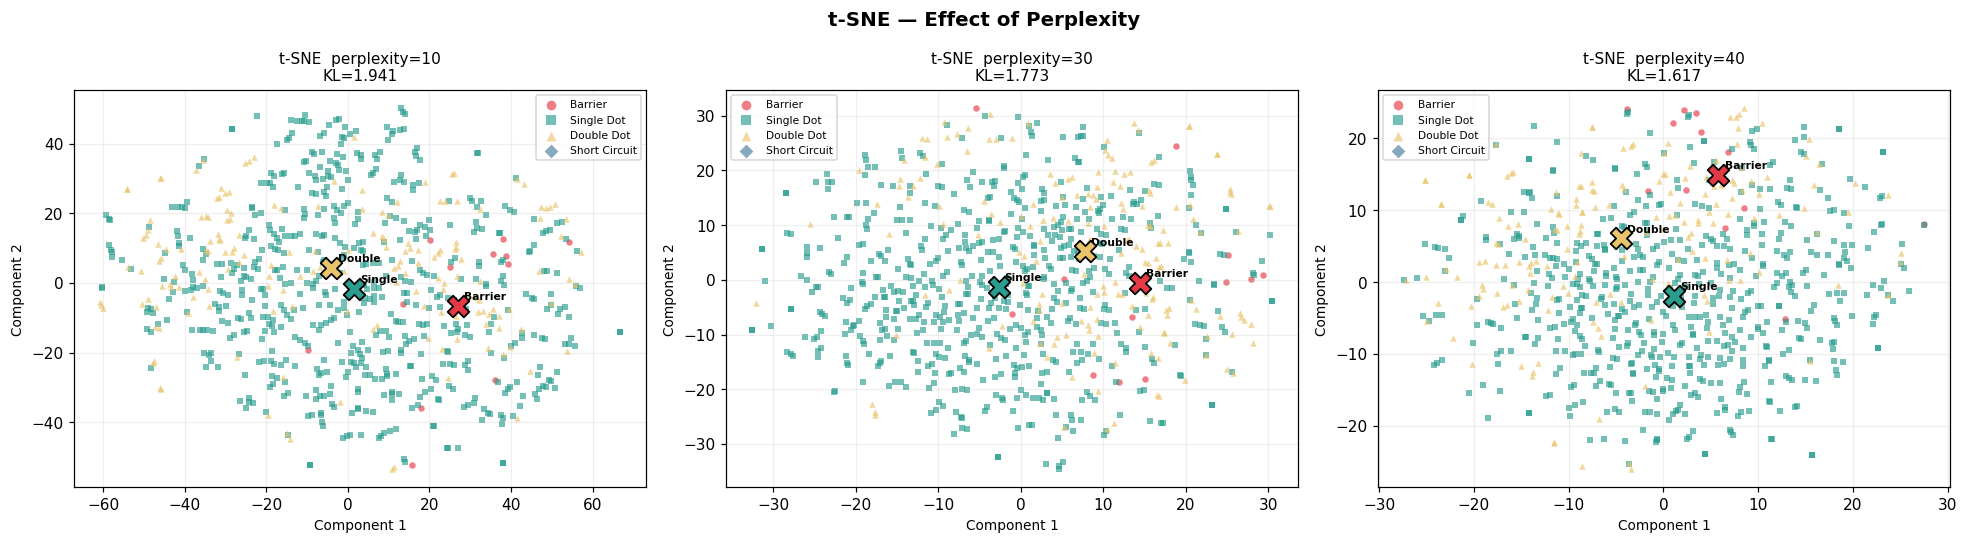

Done


In [10]:
perplexities = [10, 30, TSNE_PERPLEXITY]
tsne_results = {}

fig, axes = plt.subplots(1, len(perplexities), figsize=(6*len(perplexities), 5))
fig.suptitle("t-SNE — Effect of Perplexity", fontsize=13, fontweight="bold")

for ax, perp in zip(axes, perplexities):
    print(f"  Running t-SNE (perplexity={perp}) …", end=" ", flush=True)
    t0 = time.time()
    tsne = TSNE(n_components=2, perplexity=perp,
                n_iter_without_progress=TSNE_ITER, random_state=SEED,
                init="pca", learning_rate="auto")
    coords = tsne.fit_transform(X_sub)
    tsne_results[perp] = coords
    print(f"{time.time()-t0:.1f}s  KL={tsne.kl_divergence_:.4f}")
    scatter_2d(coords, y_sub, ax,
               title=f"t-SNE  perplexity={perp}\n"
                     f"KL={tsne.kl_divergence_:.3f}")

plt.tight_layout()
save_fig(fig, "tsne_perplexity_comparison.png")

# Best t-SNE (default perplexity) — full-size plot
X_tsne_best = tsne_results[TSNE_PERPLEXITY]


In [11]:
X_tsne_best

array([[ -0.87923586, -11.485694  ],
       [ 16.1599    ,   6.699242  ],
       [-17.982447  ,  -5.7926564 ],
       ...,
       [ 22.942585  ,  -0.76959   ],
       [  9.54668   ,   7.842633  ],
       [-15.310774  ,   8.048712  ]], dtype=float32)

## 8 · UMAP — Topology-preserving reduction

UMAP builds a topological representation of the data and optimises a  
low-dimensional layout. It is faster than t-SNE and better preserves  
global structure. We explore three (n_neighbors, min_dist) configurations.


  Running UMAP (n_neighbors=15, min_dist=0.05) … 19.4s
  Running UMAP (n_neighbors=30, min_dist=0.1) … 4.6s
  Running UMAP (n_neighbors=50, min_dist=0.5) … 5.2s


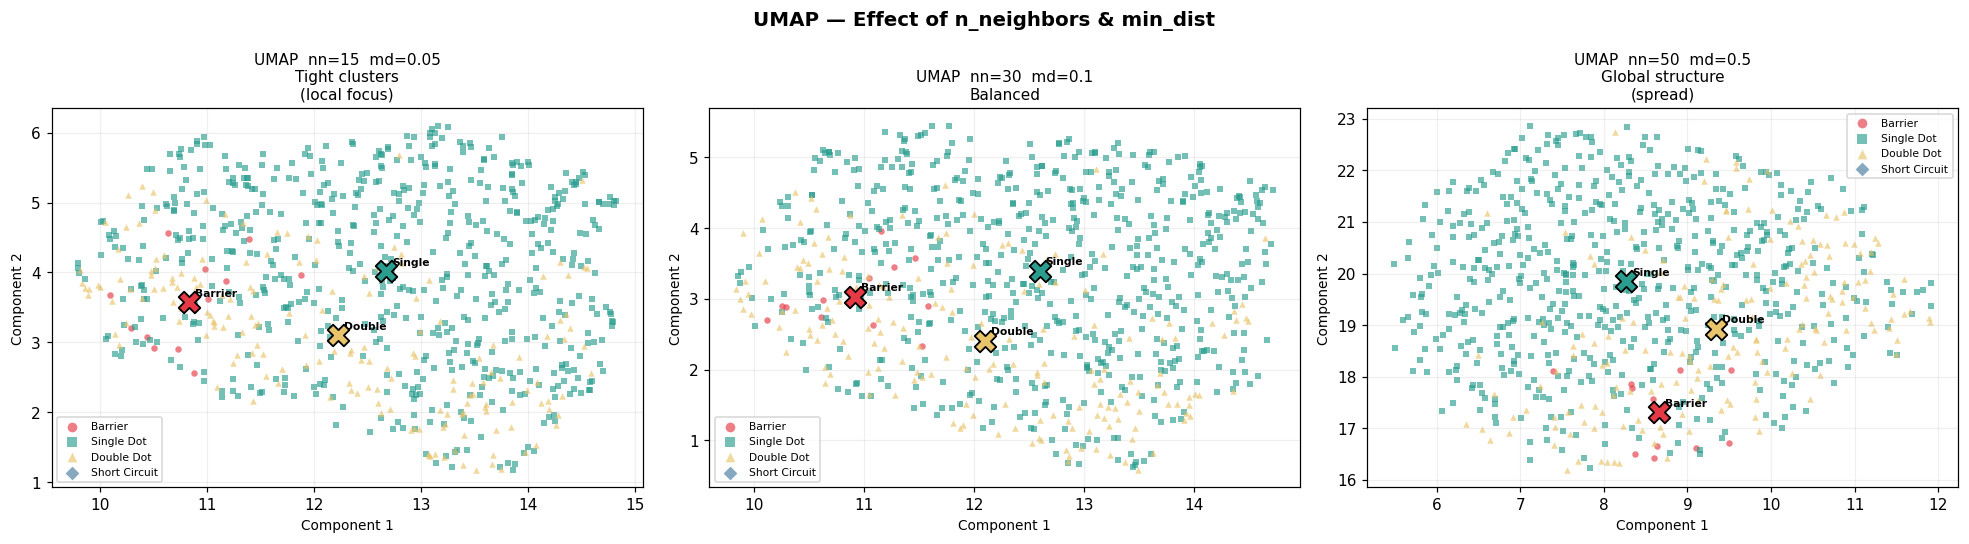

Done

  UMAP on raw 30 000-d pixels … 12.1s


In [12]:
umap_configs = [
    (15, 0.05,  "Tight clusters\n(local focus)"),
    (UMAP_N_NEIGHBORS, UMAP_MIN_DIST, "Balanced"),
    (50, 0.5,   "Global structure\n(spread)"),
]
umap_results = {}

fig, axes = plt.subplots(1, len(umap_configs), figsize=(6*len(umap_configs), 5))
fig.suptitle("UMAP — Effect of n_neighbors & min_dist",
             fontsize=13, fontweight="bold")

for ax, (nn, md_val, label) in zip(axes, umap_configs):
    print(f"  Running UMAP (n_neighbors={nn}, min_dist={md_val}) …",
          end=" ", flush=True)
    t0 = time.time()
    reducer = umap.UMAP(n_neighbors=nn, min_dist=md_val,
                        n_components=2, random_state=SEED,
                        metric="euclidean")
    coords  = reducer.fit_transform(X_sub)
    umap_results[(nn, md_val)] = coords
    print(f"{time.time()-t0:.1f}s")
    scatter_2d(coords, y_sub, ax,
               title=f"UMAP  nn={nn}  md={md_val}\n{label}")

plt.tight_layout()
save_fig(fig, "umap_config_comparison.png")

# Best UMAP
X_umap_best = umap_results[(UMAP_N_NEIGHBORS, UMAP_MIN_DIST)]

# UMAP on raw pixels (no feature extraction)
print("\n  UMAP on raw 30 000-d pixels …", end=" ", flush=True)
t0 = time.time()
X_raw_sub   = X_raw[sub_idx]
umap_raw    = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST,
                         n_components=2, random_state=SEED)
X_umap_raw  = umap_raw.fit_transform(X_raw_sub)
print(f"{time.time()-t0:.1f}s")


In [13]:
X_umap_best

array([[14.15389  ,  3.8575394],
       [11.375936 ,  4.2876825],
       [14.459642 ,  1.9718096],
       ...,
       [10.509893 ,  3.9393837],
       [11.280984 ,  3.7848783],
       [13.105402 ,  0.8828813]], dtype=float32)

## 9 · Kernel PCA · Isomap · MDS

Running Kernel PCA (RBF) … 0.1s
Running Isomap … 0.8s  reconstruction error: 314.3514
Running MDS … 24.9s  stress: 29747294.17


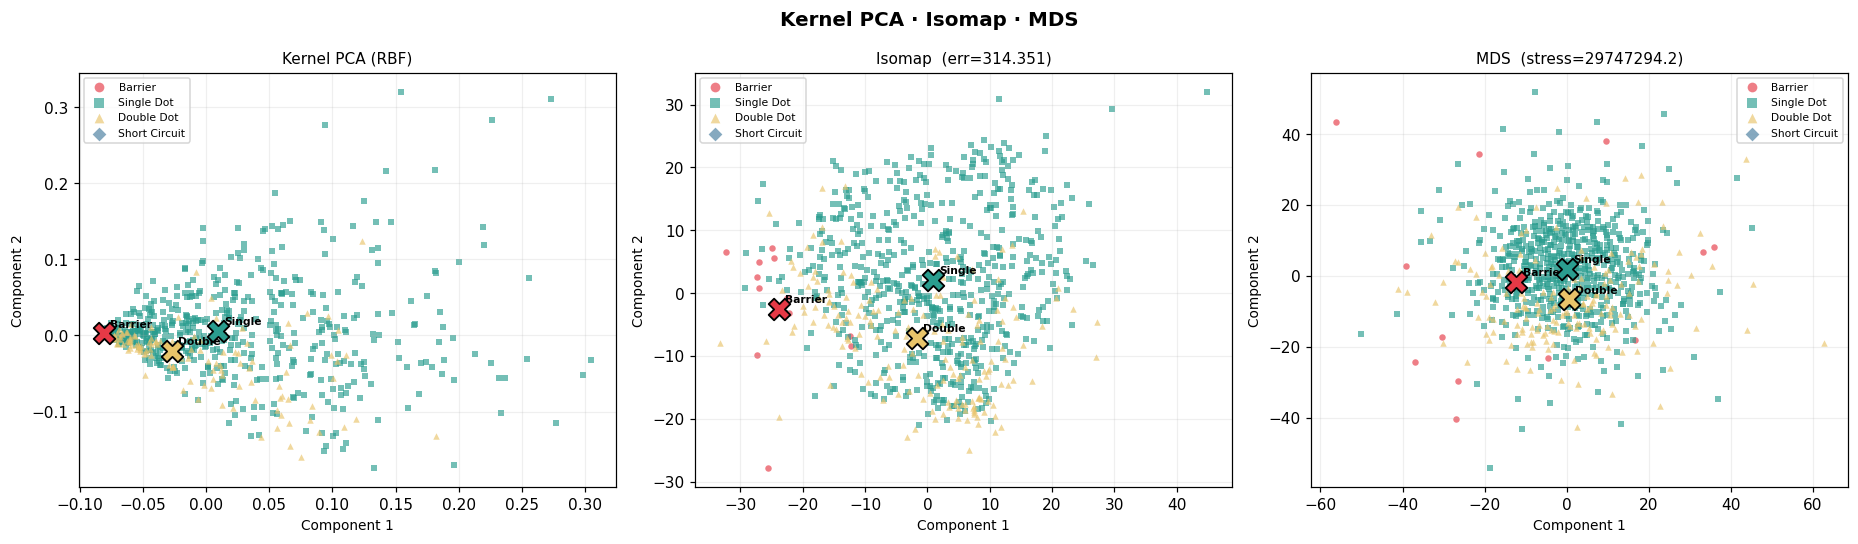

Done


In [14]:
print("Running Kernel PCA (RBF) …", end=" ", flush=True)
t0    = time.time()
kpca  = KernelPCA(n_components=2, kernel="rbf", gamma=0.01,
                  random_state=SEED)
X_kpca = kpca.fit_transform(X_sub)
print(f"{time.time()-t0:.1f}s")

print("Running Isomap …", end=" ", flush=True)
t0    = time.time()
iso   = Isomap(n_components=2, n_neighbors=15)
X_iso = iso.fit_transform(X_sub)
print(f"{time.time()-t0:.1f}s  "
      f"reconstruction error: {iso.reconstruction_error():.4f}")

print("Running MDS …", end=" ", flush=True)
t0    = time.time()
mds   = MDS(n_components=2, random_state=SEED,
            dissimilarity="euclidean", n_jobs=-1)
X_mds = mds.fit_transform(X_sub)
print(f"{time.time()-t0:.1f}s  stress: {mds.stress_:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Kernel PCA · Isomap · MDS",
             fontsize=13, fontweight="bold")

for ax, coords, title in [
    (axes[0], X_kpca, "Kernel PCA (RBF)"),
    (axes[1], X_iso,  f"Isomap  (err={iso.reconstruction_error():.3f})"),
    (axes[2], X_mds,  f"MDS  (stress={mds.stress_:.1f})"),
]:
    scatter_2d(coords, y_sub, ax, title=title)

plt.tight_layout()
save_fig(fig, "kpca_isomap_mds.png")


## 10 · All methods side-by-side comparison

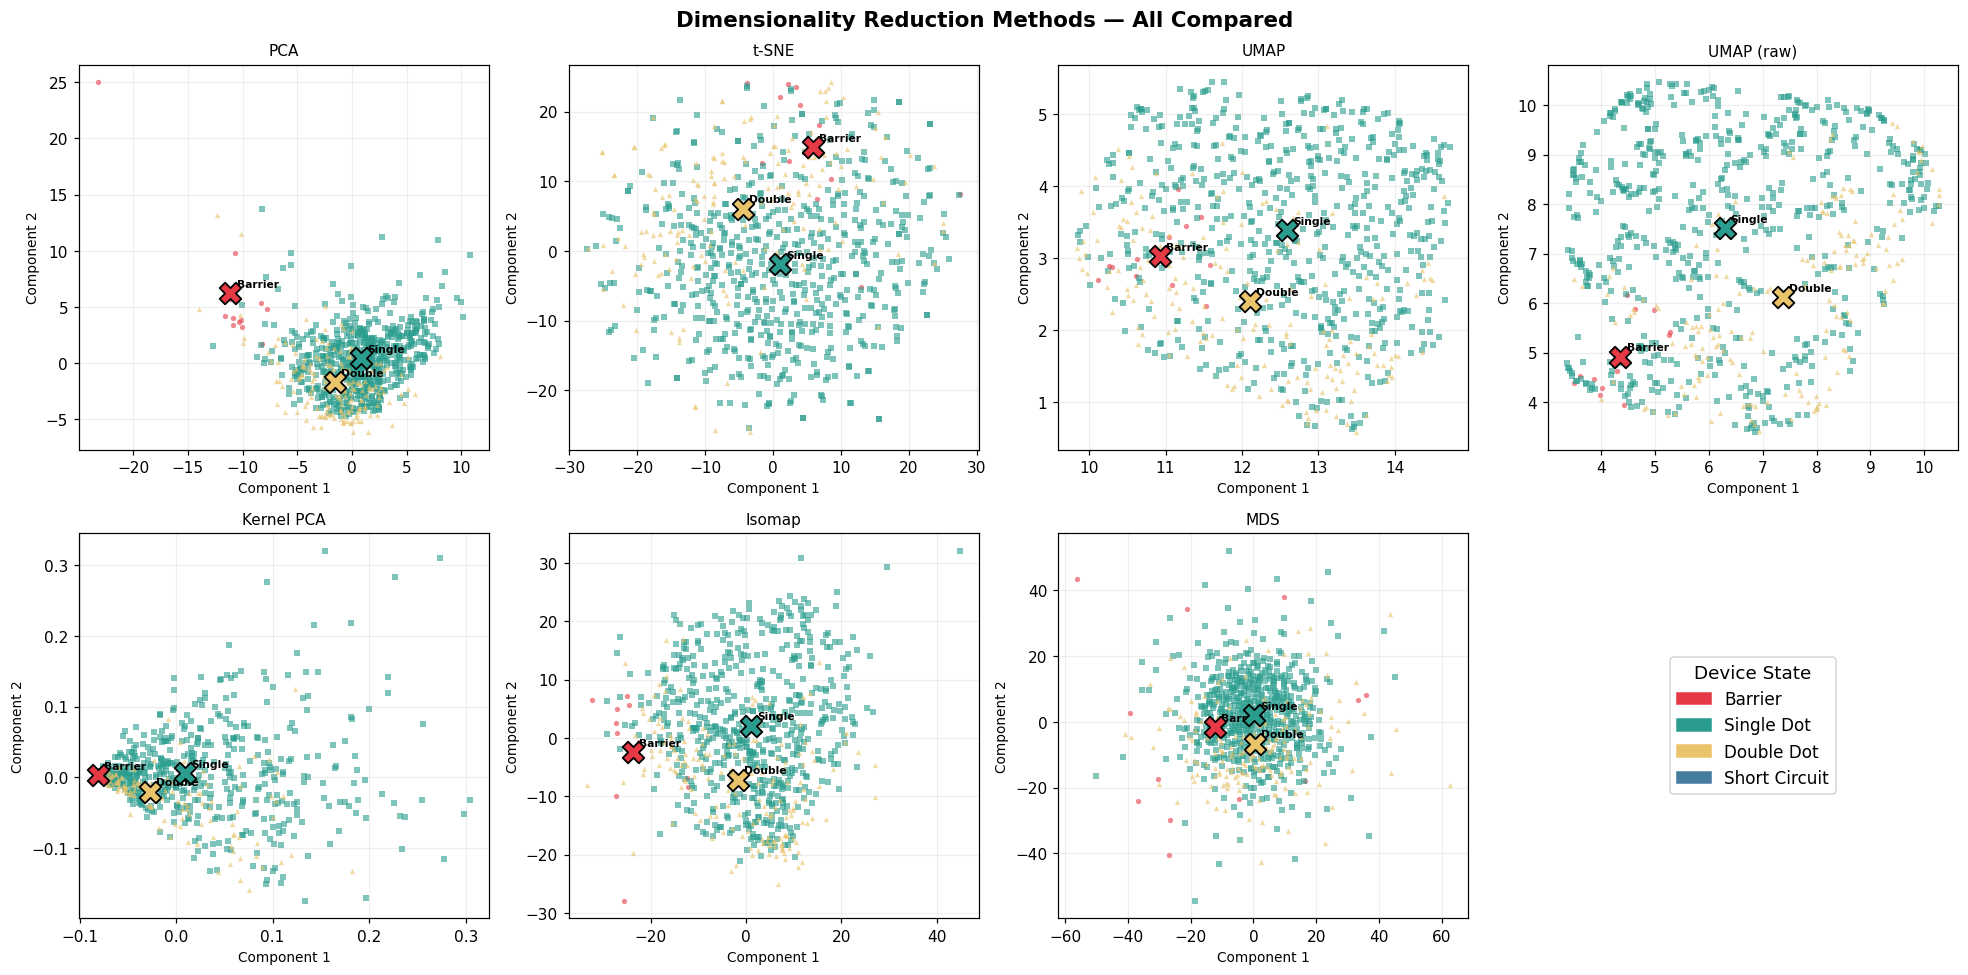

Done


In [15]:
all_methods = [
    ("PCA",         X_pca[sub_idx]),
    ("t-SNE",       X_tsne_best),
    ("UMAP",        X_umap_best),
    ("UMAP (raw)",  X_umap_raw),
    ("Kernel PCA",  X_kpca),
    ("Isomap",      X_iso),
    ("MDS",         X_mds),
]

ncols = 4; nrows = 2
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 4.5, nrows * 4.5))
axes_flat = axes.flatten()

for ax, (name, coords) in zip(axes_flat, all_methods):
    scatter_2d(coords, y_sub, ax, title=name,
               s=12, alpha=0.6, show_centroids=True, show_legend=False)

# Legend in last panel
patches = [mpatches.Patch(color=PALETTE[k], label=LABEL_NAMES[k])
           for k in ALL_LABELS]
axes_flat[len(all_methods)].axis("off")
axes_flat[len(all_methods)].legend(
    handles=patches, fontsize=11, loc="center",
    title="Device State", title_fontsize=12)

for ax in axes_flat[len(all_methods)+1:]:
    ax.axis("off")

fig.suptitle("Dimensionality Reduction Methods — All Compared",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig(fig, "all_methods_comparison.png")


## 11 · Cluster quality metrics in each embedding

Quantify how well the four device states are separated in each 2D embedding:

- **Silhouette score** — how similar each sample is to its own cluster vs others (-1 to +1, higher = better)  
- **Davies-Bouldin index** — ratio of within-cluster to between-cluster distances (lower = better)  
- **Calinski-Harabasz score** — ratio of between- to within-cluster scatter (higher = better)


Method             Silhouette ↑   Davies-Bouldin ↓   Calinski-Harabasz ↑
------------------------------------------------------------------------
  PCA                   0.0824            1.7974                 83.8
  t-SNE                -0.0031            2.5052                 33.6
  UMAP                 -0.0888            2.3746                 35.8
  UMAP (raw)           -0.0729            2.1155                 39.9
  Kernel PCA           -0.3214            2.4834                 20.5
  Isomap               -0.0045            2.2763                 40.8
  MDS                   0.1027            4.0991                 16.9


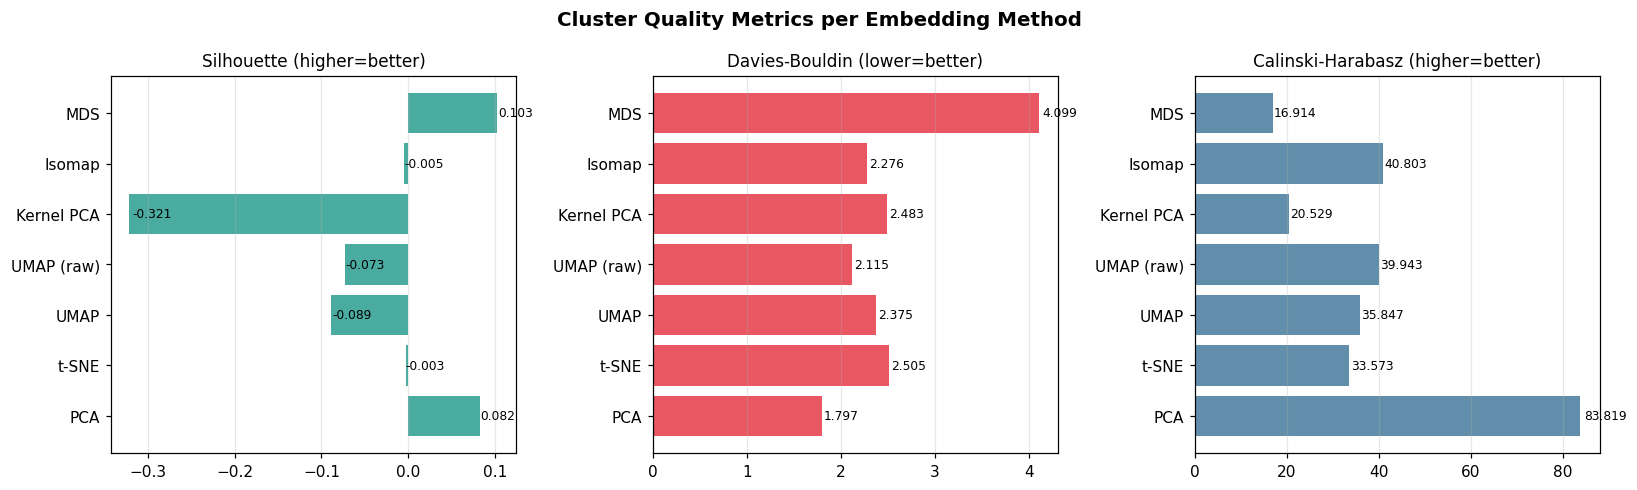

Done


In [24]:
metrics = {}
for name, coords in all_methods:
    if len(np.unique(y_sub)) < 2: continue
    try:
        sil = silhouette_score(coords, y_sub)
        db  = davies_bouldin_score(coords, y_sub)
        ch  = calinski_harabasz_score(coords, y_sub)
        metrics[name] = {"Silhouette ↑": sil, "Davies-Bouldin ↓": db,
                         "Calinski-Harabasz ↑": ch}
    except Exception as e:
        print(f"  {name}: {e}")

# Print table
print(f"{'Method':<15}  {'Silhouette ↑':>14}  "
      f"{'Davies-Bouldin ↓':>17}  {'Calinski-Harabasz ↑':>20}")
print("-"*72)
for name, m in metrics.items():
    print(f"  {name:<13}  {m['Silhouette ↑']:>13.4f}  "
          f"{m['Davies-Bouldin ↓']:>16.4f}  "
          f"{m['Calinski-Harabasz ↑']:>19.1f}")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Cluster Quality Metrics per Embedding Method",
             fontsize=13, fontweight="bold")

for ax, metric_name, color in [
    (axes[0], "Silhouette ↑",         "#2a9d8f"),
    (axes[1], "Davies-Bouldin ↓",     "#e63946"),
    (axes[2], "Calinski-Harabasz ↑",  "#457b9d"),
]:
    names  = list(metrics.keys())
    values = [metrics[n][metric_name] for n in names]
    bars   = ax.barh(names, values, color=color, alpha=0.85)
    ax.set_title(metric_name.replace("↑","(higher=better)")
                              .replace("↓","(lower=better)"))
    ax.grid(axis="x", alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + abs(bar.get_width())*0.01,
                bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
save_fig(fig, "cluster_quality_metrics.png")


## 12 · Per-class silhouette scores in best embedding

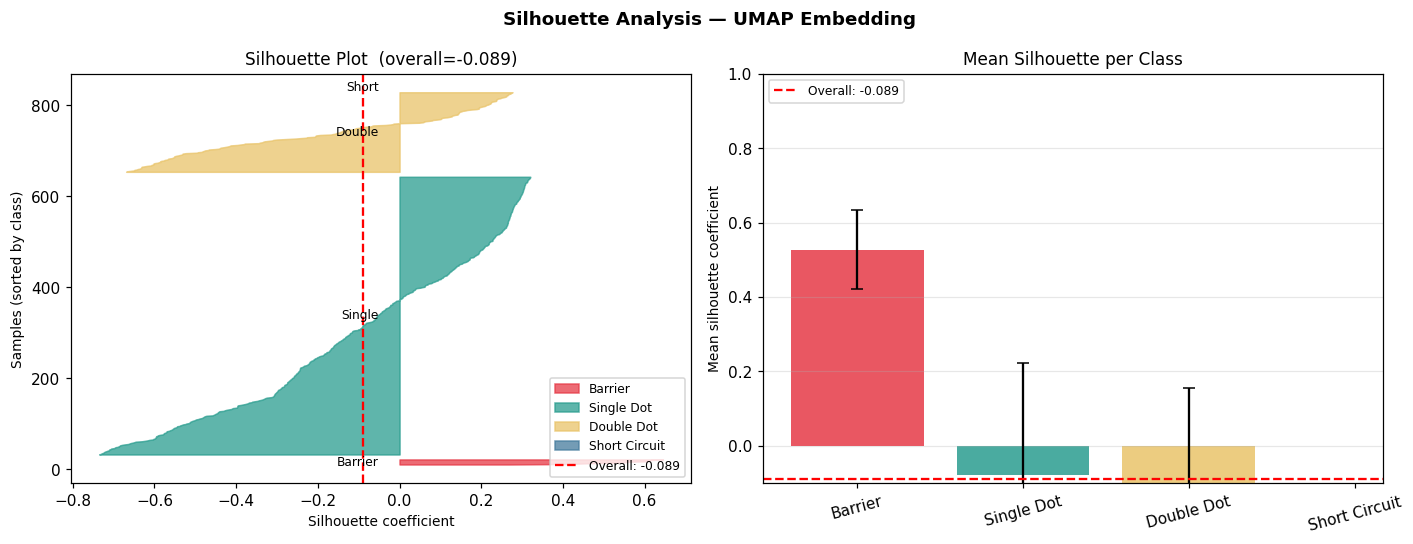

Done


In [16]:
# Use UMAP as reference embedding
best_name   = "UMAP"
best_coords = X_umap_best

sil_samples = silhouette_samples(best_coords, y_sub)
sil_overall = silhouette_score(best_coords, y_sub)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Silhouette Analysis — {best_name} Embedding",
             fontsize=12, fontweight="bold")

# Left: silhouette plot
y_lower = 10
for cls_idx in ALL_LABELS:
    cls_sil = np.sort(sil_samples[y_sub == cls_idx])
    size    = len(cls_sil)
    y_upper = y_lower + size
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, cls_sil,
                      alpha=0.75, color=PALETTE[cls_idx],
                      label=LABEL_NAMES[cls_idx])
    ax1.text(-0.05, y_lower + size/2, LABEL_NAMES[cls_idx].split()[0],
             fontsize=8, ha="right", va="center")
    y_lower = y_upper + 10

ax1.axvline(sil_overall, color="red", ls="--", lw=1.5,
            label=f"Overall: {sil_overall:.3f}")
ax1.set_xlabel("Silhouette coefficient")
ax1.set_ylabel("Samples (sorted by class)")
ax1.set_title(f"Silhouette Plot  (overall={sil_overall:.3f})")
ax1.legend(fontsize=8, loc="lower right")

# Right: mean ± std per class
per_class_mean = [sil_samples[y_sub==k].mean() for k in ALL_LABELS]
per_class_std  = [sil_samples[y_sub==k].std()  for k in ALL_LABELS]
x_pos = np.arange(N_CLASSES)
ax2.bar(x_pos, per_class_mean, color=PALETTE, alpha=0.85,
        yerr=per_class_std, capsize=4, ecolor="black", linewidth=0.8)
ax2.axhline(sil_overall, color="red", ls="--", lw=1.5,
            label=f"Overall: {sil_overall:.3f}")
ax2.set_xticks(x_pos); ax2.set_xticklabels(CLASS_NAMES, rotation=15)
ax2.set_ylabel("Mean silhouette coefficient")
ax2.set_title("Mean Silhouette per Class")
ax2.legend(fontsize=8); ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(-0.1, 1.0)

plt.tight_layout()
save_fig(fig, "silhouette_analysis.png")


## 13 · Cosine similarity between class centroids (high-dimensional)

Compute centroids in the full 426-d feature space and measure  
cosine similarity between every pair of device state centroids.  
Values close to 1 = nearly identical feature profiles.


Valid classes: [0, 1, 2]


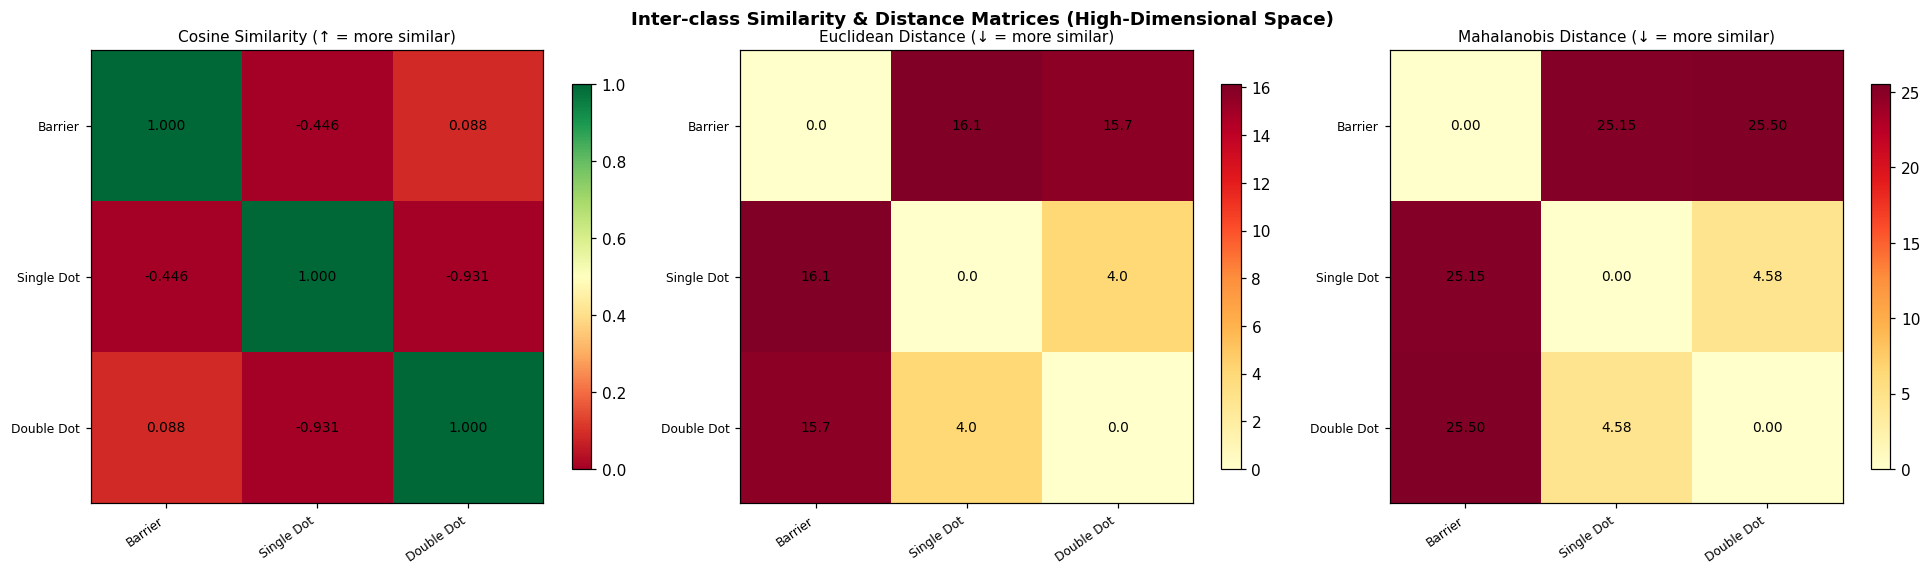

Done

Cosine Similarity (high value = similar feature profiles):
          Barrier  ↔  Single Dot     : -0.4464
          Barrier  ↔  Double Dot     : 0.0881
       Single Dot  ↔  Double Dot     : -0.9307


In [17]:
valid_labels = [k for k in ALL_LABELS if np.any(labels == k)]
print("Valid classes:", valid_labels)

class_names_valid = [LABEL_NAMES[k] for k in valid_labels]
N_VALID = len(valid_labels)

# ── Compute centroids safely ──────────────────────────────────────────────────
centroids = np.array([
    X_sc[labels == k].mean(axis=0)
    for k in valid_labels
])  # (N_VALID, D)

# ── Cosine similarity ─────────────────────────────────────────────────────────
norms = np.linalg.norm(centroids, axis=1, keepdims=True)
cent_norm = centroids / (norms + 1e-10)
cos_sim = cent_norm @ cent_norm.T

# ── Euclidean distance ────────────────────────────────────────────────────────
from scipy.spatial.distance import pdist, squareform
euc_dist = squareform(pdist(centroids, metric="euclidean"))

# ── Mahalanobis distance (FIXED + stabilized) ─────────────────────────────────
D = X_sc.shape[1]
cov_pooled = np.zeros((D, D))
total_samples = 0

for k in valid_labels:
    Xk = X_sc[labels == k]
    if len(Xk) < 2:
        continue
    cov_k = np.cov(Xk.T)
    cov_pooled += cov_k * (len(Xk) - 1)
    total_samples += (len(Xk) - 1)

cov_pooled /= max(total_samples, 1)

# ✅ Critical: regularization for numerical stability
cov_pooled += np.eye(D) * 1e-5

try:
    cov_inv = np.linalg.pinv(cov_pooled)

    mah_dist = np.zeros((N_VALID, N_VALID))
    for i in range(N_VALID):
        for j in range(N_VALID):
            diff = centroids[i] - centroids[j]
            mah_dist[i, j] = np.sqrt(max(diff @ cov_inv @ diff, 0))

    mah_ok = True

except Exception as e:
    print(f"Mahalanobis failed: {e}")
    mah_ok = False

# ── Plotting ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3 if mah_ok else 2,
                         figsize=(6 * (3 if mah_ok else 2), 5))

fig.suptitle(
    "Inter-class Similarity & Distance Matrices (High-Dimensional Space)",
    fontsize=12,
    fontweight="bold"
)

def plot_matrix(mat, ax, title, cmap, fmt=".3f", vmin=None, vmax=None):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(range(N_VALID))
    ax.set_yticks(range(N_VALID))
    ax.set_xticklabels(class_names_valid, rotation=35, ha="right", fontsize=8)
    ax.set_yticklabels(class_names_valid, fontsize=8)
    ax.set_title(title, fontsize=10)

    plt.colorbar(im, ax=ax, shrink=0.85)

    for i in range(N_VALID):
        for j in range(N_VALID):
            ax.text(j, i, format(mat[i, j], fmt),
                    ha="center", va="center", fontsize=9)

plot_matrix(cos_sim, axes[0],
            "Cosine Similarity (↑ = more similar)",
            "RdYlGn", vmin=0, vmax=1)

plot_matrix(euc_dist, axes[1],
            "Euclidean Distance (↓ = more similar)",
            "YlOrRd", fmt=".1f")

if mah_ok:
    plot_matrix(mah_dist, axes[2],
                "Mahalanobis Distance (↓ = more similar)",
                "YlOrRd", fmt=".2f")

plt.tight_layout()
save_fig(fig, "similarity_matrices.png")

# ── Print similarity summary ──────────────────────────────────────────────────
print("\nCosine Similarity (high value = similar feature profiles):")
for i in range(N_VALID):
    for j in range(i + 1, N_VALID):
        print(f"  {class_names_valid[i]:>15}  ↔  {class_names_valid[j]:<15}: "
              f"{cos_sim[i, j]:.4f}")

## 14 · k-Nearest Neighbour purity in high-dimensional space

For each sample, find its k nearest neighbours in the 426-d feature space  
and measure what fraction belong to the same class.  
High purity = tight, well-separated clusters.


Overall 15-NN purity: 75.38%
(% of neighbours belonging to same class)
  Barrier        : 1.85%
  Single Dot     : 92.59%
  Double Dot     : 23.88%
  Short Circuit  : nan%


posx and posy should be finite values
posx and posy should be finite values


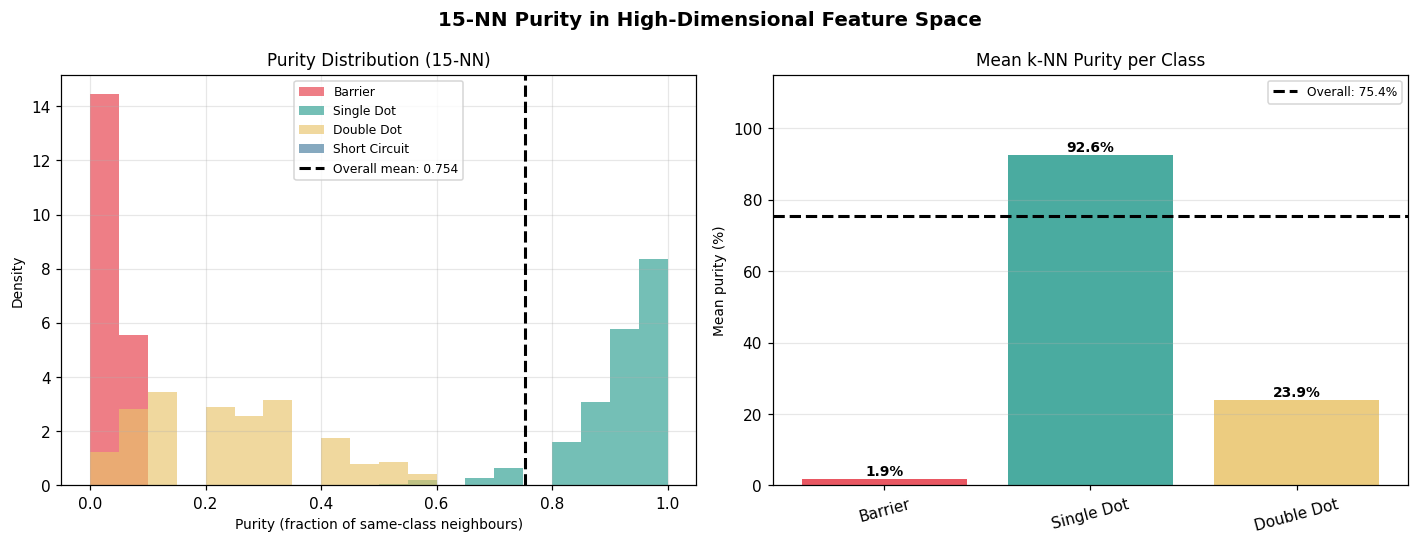

Done


In [18]:
k = N_NEIGHBORS_KNN
nbrs = NearestNeighbors(n_neighbors=k+1, metric="euclidean",
                         n_jobs=-1).fit(X_sc)
distances, indices = nbrs.kneighbors(X_sc)

# Exclude self (index 0)
neighbour_labels = labels[indices[:, 1:]]   # (N, k)
same_class       = (neighbour_labels == labels[:, np.newaxis])
purity_per_sample = same_class.mean(axis=1)   # (N,)

overall_purity = purity_per_sample.mean()
print(f"Overall {k}-NN purity: {overall_purity*100:.2f}%")
print(f"(% of neighbours belonging to same class)")

per_class_purity = {}
for cls_idx in ALL_LABELS:
    mask = labels == cls_idx
    per_class_purity[cls_idx] = purity_per_sample[mask].mean()
    print(f"  {LABEL_NAMES[cls_idx]:<15}: {per_class_purity[cls_idx]*100:.2f}%")

# Purity distribution plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"{k}-NN Purity in High-Dimensional Feature Space",
             fontsize=13, fontweight="bold")

# Histogram per class
bins = np.linspace(0, 1, 21)
for cls_idx in ALL_LABELS:
    mask = labels == cls_idx
    axes[0].hist(purity_per_sample[mask], bins=bins, alpha=0.65,
                 color=PALETTE[cls_idx], label=LABEL_NAMES[cls_idx],
                 density=True)
axes[0].axvline(overall_purity, color="black", ls="--", lw=2,
                label=f"Overall mean: {overall_purity:.3f}")
axes[0].set_xlabel("Purity (fraction of same-class neighbours)")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Purity Distribution ({k}-NN)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bar chart per class
bar_vals = [per_class_purity[k]*100 for k in ALL_LABELS]
bars = axes[1].bar(CLASS_NAMES, bar_vals, color=PALETTE, alpha=0.85)
axes[1].axhline(overall_purity*100, color="black", ls="--", lw=2,
                label=f"Overall: {overall_purity*100:.1f}%")
axes[1].set_ylabel("Mean purity (%)"); axes[1].set_ylim(0, 115)
axes[1].set_title("Mean k-NN Purity per Class")
axes[1].legend(fontsize=8); axes[1].grid(axis="y", alpha=0.3)
for bar, v in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1,
                 f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
plt.xticks(rotation=15)

plt.tight_layout()
save_fig(fig, "knn_purity.png")


## 15 · Pairwise distance heatmap

Sample a balanced subset and compute the full N×N distance matrix.  
Blocks along the diagonal should be darker (intra-class distances small)  
if classes form compact, well-separated clusters.


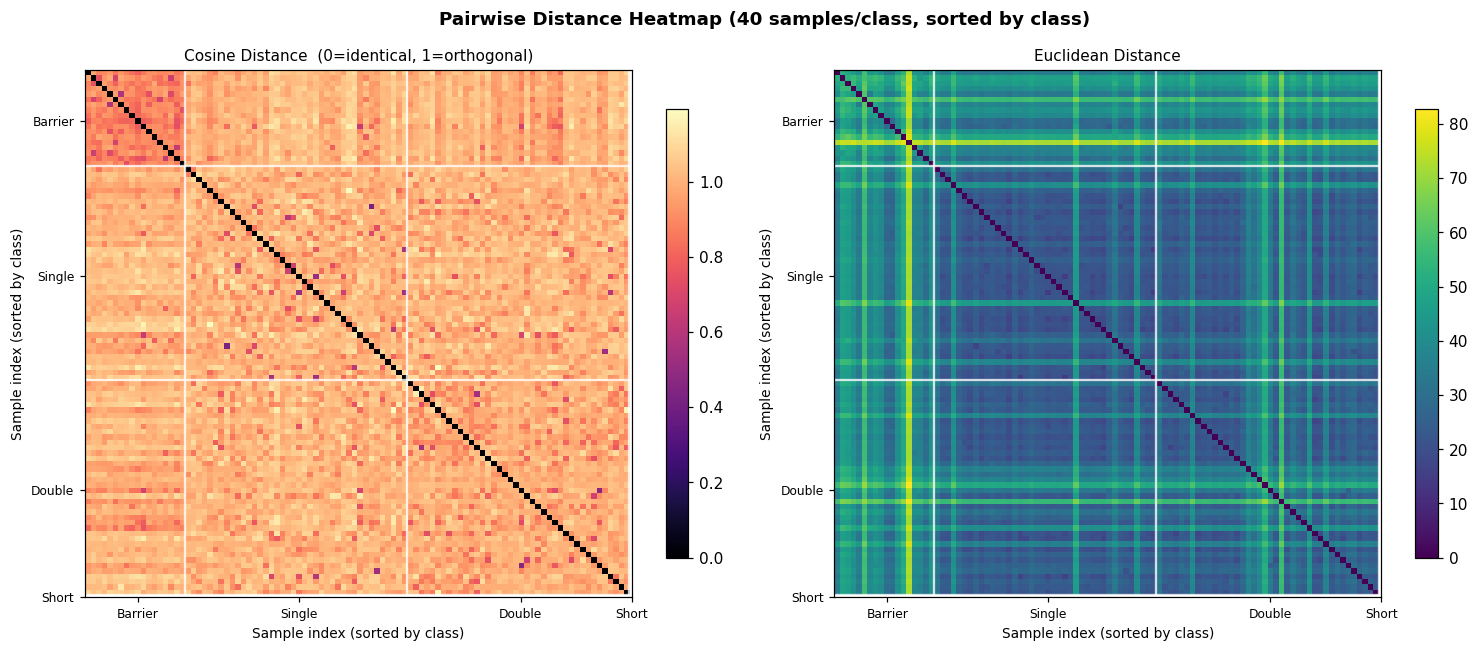

Done


In [19]:
# Balanced subsample for heatmap
N_PER_CLASS = 40
hm_idx = []
for cls_idx in ALL_LABELS:
    cls_idxs = np.where(labels == cls_idx)[0]
    chosen   = np.random.RandomState(SEED).choice(
        cls_idxs, min(N_PER_CLASS, len(cls_idxs)), replace=False)
    hm_idx.extend(chosen.tolist())
hm_idx  = np.array(hm_idx)
X_hm    = X_sc[hm_idx]
y_hm    = labels[hm_idx]

# Sort by class label for block structure
sort_ord = np.argsort(y_hm, kind="stable")
X_hm_s  = X_hm[sort_ord]
y_hm_s  = y_hm[sort_ord]

# Cosine + Euclidean pairwise
cos_D   = pairwise_distances(X_hm_s, metric="cosine")
euc_D   = pairwise_distances(X_hm_s, metric="euclidean")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Pairwise Distance Heatmap "
             f"({N_PER_CLASS} samples/class, sorted by class)",
             fontsize=12, fontweight="bold")

for ax, D, title, cmap in [
    (axes[0], cos_D, "Cosine Distance  (0=identical, 1=orthogonal)",  "magma"),
    (axes[1], euc_D, "Euclidean Distance",                             "viridis"),
]:
    im = ax.imshow(D, cmap=cmap, aspect="auto")
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Sample index (sorted by class)")
    ax.set_ylabel("Sample index (sorted by class)")

    # Draw class boundary lines
    cumulative = 0
    for cls_idx in ALL_LABELS[:-1]:
        cumulative += (y_hm_s == cls_idx).sum()
        for a in [ax]:
            a.axhline(cumulative - 0.5, color="white", lw=1.5, alpha=0.8)
            a.axvline(cumulative - 0.5, color="white", lw=1.5, alpha=0.8)

    # Class labels on axes
    tick_pos, tick_lbl = [], []
    start = 0
    for cls_idx in ALL_LABELS:
        n = (y_hm_s == cls_idx).sum()
        tick_pos.append(start + n//2)
        tick_lbl.append(LABEL_NAMES[cls_idx].split()[0])
        start += n
    ax.set_xticks(tick_pos); ax.set_xticklabels(tick_lbl, fontsize=8)
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lbl, fontsize=8)

plt.tight_layout()
save_fig(fig, "pairwise_distance_heatmap.png")


## 16 · Nearest-neighbour retrieval

For a query sample from each class, retrieve its 5 nearest neighbours  
in the 426-d feature space and display all current maps.  
If retrieval is accurate, the neighbours should look visually similar  
and belong to the same class.


Using classes: [0, 1, 2]


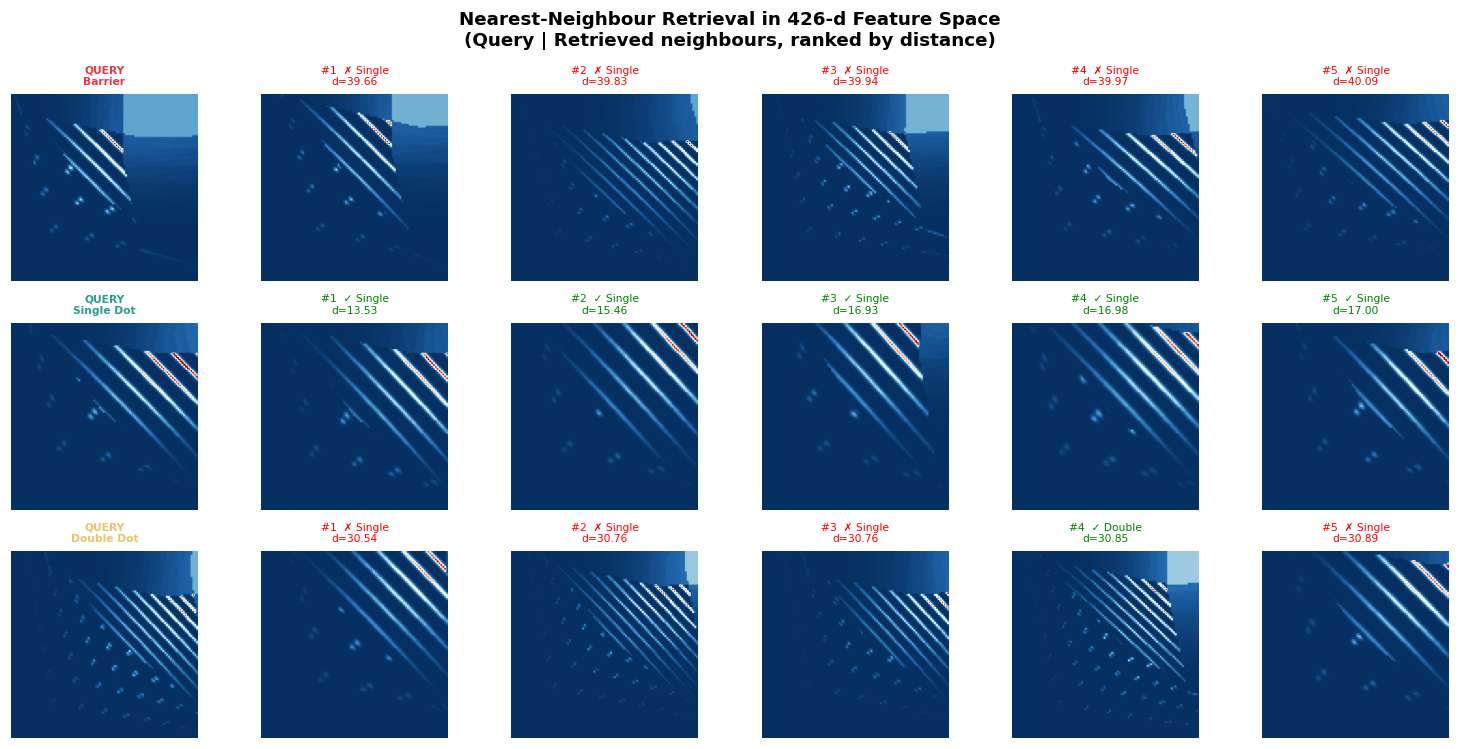

In [20]:
def log_display(maps):
    """Log-scale and normalise a map for display."""
    m  = np.log1p(np.abs(maps))
    mn = m.min(); mx = m.max()
    return (m - mn) / (mx - mn + 1e-8)


# ── ✅ Only use classes that exist ────────────────────────────────────────────
valid_labels = [k for k in ALL_LABELS if np.any(labels == k)]
N_VALID = len(valid_labels)

print("Using classes:", valid_labels)

nbrs_full = NearestNeighbors(
    n_neighbors=N_SIMILAR_SHOW + 1, metric="euclidean", n_jobs=-1
).fit(X_sc)

fig, big_axes = plt.subplots(
    N_VALID, N_SIMILAR_SHOW + 1,
    figsize=((N_SIMILAR_SHOW + 1) * 2.3, N_VALID * 2.3)
)

fig.suptitle(
    "Nearest-Neighbour Retrieval in 426-d Feature Space\n"
    "(Query | Retrieved neighbours, ranked by distance)",
    fontsize=12, fontweight="bold"
)

# Ensure axes is always 2D (important when N_VALID == 1)
if N_VALID == 1:
    big_axes = np.expand_dims(big_axes, axis=0)

for row, cls_idx in enumerate(valid_labels):

    cls_pool = np.where(labels == cls_idx)[0]

    # ✅ Safety check (extra protection)
    if len(cls_pool) == 0:
        print(f"Skipping class {cls_idx} — no samples")
        continue

    query_idx = int(np.random.RandomState(SEED + cls_idx).choice(cls_pool))
    query_ft  = X_sc[query_idx:query_idx+1]

    dists, idxs = nbrs_full.kneighbors(query_ft)
    retrieved = idxs[0, 1:]  # skip self

    # ── Query ───────────────────────────────────────────────────────────────
    ax = big_axes[row, 0]
    ax.imshow(log_display(current[query_idx]),
              cmap="RdBu_r", origin="lower")

    ax.set_title(
        f"QUERY\n{LABEL_NAMES[cls_idx]}",
        fontsize=7,
        color=PALETTE[cls_idx],
        fontweight="bold"
    )
    ax.axis("off")

    for spine in ax.spines.values():
        spine.set_edgecolor(PALETTE[cls_idx])
        spine.set_linewidth(3)

    # ── Retrieved neighbours ────────────────────────────────────────────────
    for col, ret_idx in enumerate(retrieved[:N_SIMILAR_SHOW], start=1):
        ax = big_axes[row, col]
        ax.imshow(log_display(current[ret_idx]),
                  cmap="RdBu_r", origin="lower")

        match = "✓" if labels[ret_idx] == cls_idx else "✗"
        color = "green" if labels[ret_idx] == cls_idx else "red"

        ax.set_title(
            f"#{col}  {match} {LABEL_NAMES[labels[ret_idx]].split()[0]}\n"
            f"d={dists[0, col]:.2f}",
            fontsize=7,
            color=color
        )
        ax.axis("off")

plt.tight_layout()
plt.show()


## 17 · UMAP embedding with density contours

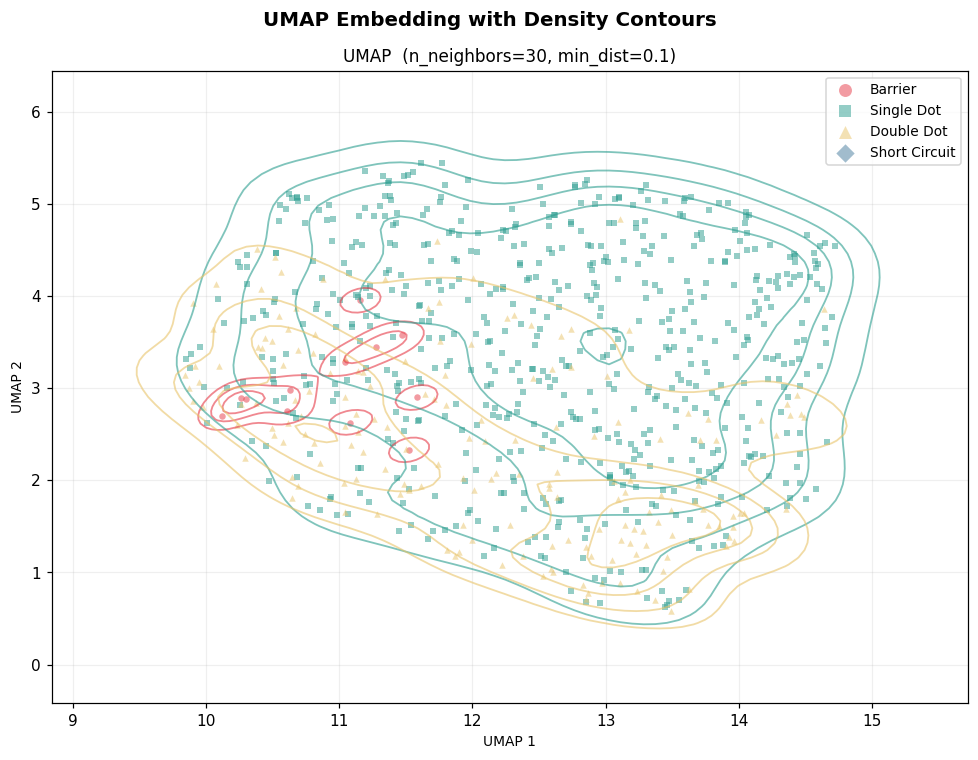

Done


In [25]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("UMAP Embedding with Density Contours",
             fontsize=13, fontweight="bold")

for cls_idx in ALL_LABELS:
    mask = y_sub == cls_idx
    pts  = X_umap_best[mask]

    ax.scatter(pts[:, 0], pts[:, 1],
               c=PALETTE[cls_idx], marker=MARKERS[cls_idx],
               s=18, alpha=0.5, linewidths=0,
               label=LABEL_NAMES[cls_idx])

    # KDE contour
    if mask.sum() > 10:
        try:
            kde = gaussian_kde(pts.T, bw_method=0.3)
            xmin, xmax = pts[:,0].min()-1, pts[:,0].max()+1
            ymin, ymax = pts[:,1].min()-1, pts[:,1].max()+1
            xx, yy = np.mgrid[xmin:xmax:80j, ymin:ymax:80j]
            zz     = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            ax.contour(xx, yy, zz, levels=4,
                       colors=[PALETTE[cls_idx]], alpha=0.6, linewidths=1.2)
        except Exception:
            pass

ax.legend(fontsize=9, markerscale=2)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_title(f"UMAP  (n_neighbors={UMAP_N_NEIGHBORS}, min_dist={UMAP_MIN_DIST})")
ax.grid(alpha=0.2)
plt.tight_layout()
save_fig(fig, "umap_density_contours.png")


## 18 · Trustworthiness score

Trustworthiness measures how faithfully each 2D embedding preserves  
the local neighbourhood structure of the original high-dimensional space.  
Score = 1.0 means every sample's k-NN in 2D exactly matches its  
k-NN in the original space.


  PCA            : 0.6095
  t-SNE          : 0.6725
  UMAP           : 0.6405
  UMAP (raw)     : 0.6608
  Kernel PCA     : 0.5634
  Isomap         : 0.5972
  MDS            : 0.5785


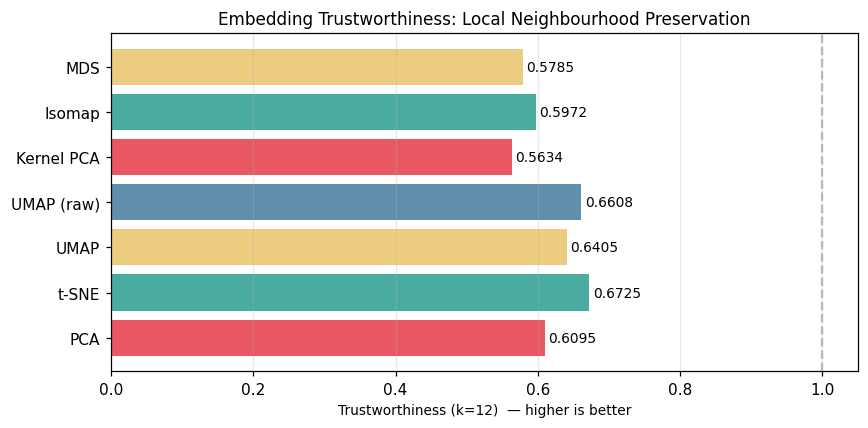

Done


In [26]:
from sklearn.manifold import trustworthiness

k_trust = 12
trust_results = {}

for name, coords in all_methods:
    try:
        t = trustworthiness(X_sub, coords, n_neighbors=k_trust)
        trust_results[name] = t
        print(f"  {name:<15}: {t:.4f}")
    except Exception as e:
        print(f"  {name:<15}: ERROR — {e}")

fig, ax = plt.subplots(figsize=(8, 4))
names  = list(trust_results.keys())
values = list(trust_results.values())
colors_bar = [PALETTE[i % 4] for i in range(len(names))]
bars   = ax.barh(names, values, color=colors_bar, alpha=0.85)
ax.set_xlim(0, 1.05)
ax.set_xlabel(f"Trustworthiness (k={k_trust})  — higher is better")
ax.set_title("Embedding Trustworthiness: Local Neighbourhood Preservation")
ax.axvline(1.0, color="grey", ls="--", alpha=0.5)
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
save_fig(fig, "trustworthiness.png")


## 19 · Summary

In [27]:
print("\n" + "="*65)
print("  Dimensionality Reduction & Similarity Analysis — Summary")
print("="*65)

print("\n  CLUSTER QUALITY (2D embeddings)")
print(f"  {'Method':<15}  {'Silhouette ↑':>13}  "
      f"{'Davies-Bouldin ↓':>17}  {'Trustworthiness ↑':>18}")
print("  " + "-"*68)
for name in [m[0] for m in all_methods]:
    sil  = metrics.get(name, {}).get("Silhouette ↑", float("nan"))
    db   = metrics.get(name, {}).get("Davies-Bouldin ↓", float("nan"))
    tr   = trust_results.get(name, float("nan"))
    print(f"  {name:<15}  {sil:>13.4f}  {db:>17.4f}  {tr:>18.4f}")

print("\n  HIGH-DIMENSIONAL SIMILARITY")
print(f"  Overall {k}-NN Purity : {overall_purity*100:.2f}%")
print(f"  Overall Silhouette   : {silhouette_score(X_sc, labels):.4f}")
print(f"  Davies-Bouldin       : {davies_bouldin_score(X_sc, labels):.4f}")
print(f"  Calinski-Harabasz    : {calinski_harabasz_score(X_sc, labels):.1f}")

print("\n  COSINE SIMILARITY BETWEEN CLASS CENTROIDS")
for i in ALL_LABELS:
    for j in ALL_LABELS:
        if i < j:
            print(f"    {LABEL_NAMES[i]:>15}  ↔  {LABEL_NAMES[j]:<15}: "
                  f"{cos_sim[i,j]:.4f}")




  Dimensionality Reduction & Similarity Analysis — Summary

  CLUSTER QUALITY (2D embeddings)
  Method            Silhouette ↑   Davies-Bouldin ↓   Trustworthiness ↑
  --------------------------------------------------------------------
  PCA                     0.0824             1.7974              0.6095
  t-SNE                  -0.0031             2.5052              0.6725
  UMAP                   -0.0888             2.3746              0.6405
  UMAP (raw)             -0.0729             2.1155              0.6608
  Kernel PCA             -0.3214             2.4834              0.5634
  Isomap                 -0.0045             2.2763              0.5972
  MDS                     0.1027             4.0991              0.5785

  HIGH-DIMENSIONAL SIMILARITY
  Overall 15-NN Purity : 75.38%
  Overall Silhouette   : 0.0416
  Davies-Bouldin       : 7.6160
  Calinski-Harabasz    : 8.8

  COSINE SIMILARITY BETWEEN CLASS CENTROIDS
            Barrier  ↔  Single Dot     : -0.4464
        

IndexError: index 3 is out of bounds for axis 1 with size 3